In [58]:
import pandas as pd

esg = pd.read_csv("ESGData.csv")
country_info = pd.read_csv("ESGCountry.csv")

real_countries = country_info[country_info["Region"].notna()]["Country Code"]

year_columns = [str(y) for y in range(1990, 2015)]

co2 = esg[esg["Indicator Name"] == "CO2 emissions (metric tons per capita)"]
co2_countries = co2[co2["Country Code"].isin(real_countries)]

chile = co2[co2["Country Name"] == "Chile"]
gdp_row = esg[(esg["Country Name"] == "Chile") &
               (esg["Indicator Name"] == "GDP growth (annual %)")]

In [59]:
chile_long = chile.melt(id_vars=["Country Name"], value_vars=year_columns,
                          var_name="Year", value_name="CO2_per_capita")

gdp_long = gdp_row.melt(id_vars=["Country Name"], value_vars=year_columns,
                          var_name="Year", value_name="GDP_growth")

In [60]:
combined = chile_long.merge(gdp_long, on=["Country Name", "Year"])
combined.head()

,Country Name,Year,CO2_per_capita,GDP_growth
0,Chile,1990,2.509653,3.333565
1,Chile,1991,2.321076,7.804392
2,Chile,1992,2.367010,11.166708
3,Chile,1993,2.483158,6.588784
4,Chile,1994,2.689742,5.030198


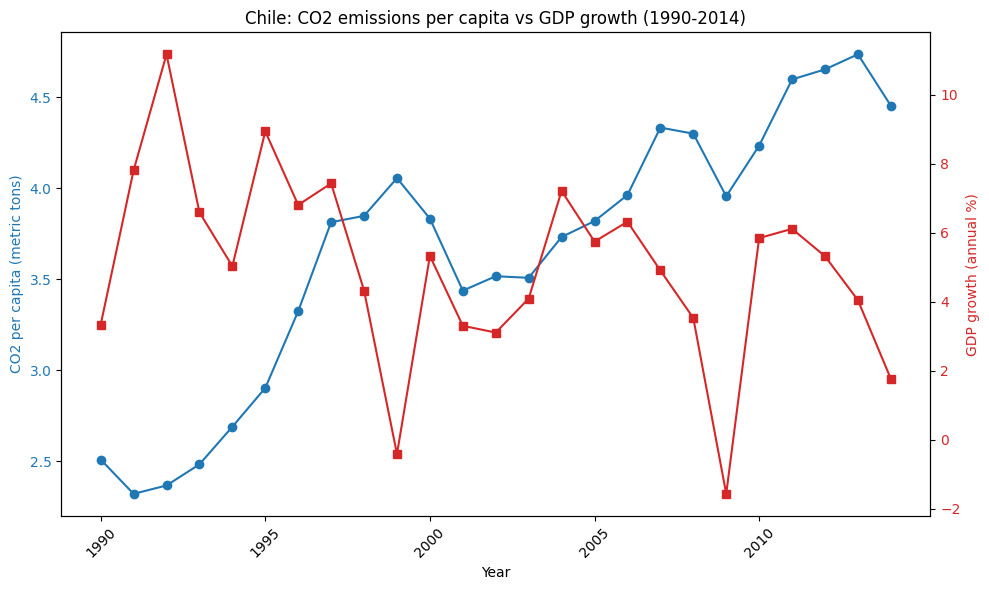

In [61]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(combined["Year"], combined["CO2_per_capita"], color="tab:blue", marker="o", label="CO2 per capita")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 per capita (metric tons)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
plt.xticks(combined["Year"][::5], rotation=45)

ax2 = ax1.twinx()
ax2.plot(combined["Year"], combined["GDP_growth"], color="tab:red", marker="s", label="GDP growth (%)")
ax2.set_ylabel("GDP growth (annual %)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

plt.title("Chile: CO2 emissions per capita vs GDP growth (1990-2014)")
fig.tight_layout()
plt.savefig("chile_co2_vs_gdp.png", bbox_inches="tight", dpi=150)
plt.show()

While Chile's CO2 emissions per capita rose fairly steadily from 1990-2014, GDP growth (annual %) fluctuated without a clear matching pattern. This suggests emissions may track cumulative economic size (GDP level) rather than year-to-year growth rate, a distinction worth exploring further, and a reminder that correlation analysis requires comparing the right type of variable, not just any two related metrics.

In [62]:
gdp_data = pd.read_csv("GDP by Country.csv", skiprows=4)
gdp_data.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,Unnamed: 62
0,Aruba,ABW,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,2.498933e+09,2.467704e+09,2.584464e+09,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AFG,GDP (current US$),NY.GDP.MKTP.CD,5.377778e+08,5.488889e+08,5.466667e+08,7.511112e+08,8.000000e+08,1.006667e+09,...,1.248694e+10,1.593680e+10,1.793024e+10,2.053654e+10,2.004633e+10,2.005019e+10,1.921556e+10,1.946902e+10,NaN,NaN
2,Angola,AGO,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,7.549238e+10,8.247091e+10,1.041159e+11,1.153984e+11,1.249121e+11,1.267769e+11,1.029622e+11,9.533511e+10,NaN,NaN
3,Albania,ALB,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,1.204421e+10,1.192695e+10,1.289087e+10,1.231978e+10,1.277628e+10,1.322824e+10,1.133526e+10,1.186387e+10,NaN,NaN
4,Andorra,AND,GDP (current US$),NY.GDP.MKTP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,3.660531e+09,3.355695e+09,3.442063e+09,3.164615e+09,3.281585e+09,3.350736e+09,2.811489e+09,2.858518e+09,NaN,NaN


In [63]:
gdp_level = gdp_data[gdp_data["Country Name"] == "Chile"]
gdp_level

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2009,2010,2011,2012,2013,2014,2015,2016,2017,Unnamed: 62
37,Chile,CHL,GDP (current US$),NY.GDP.MKTP.CD,4.110000e+09,4.609727e+09,5.416273e+09,5.668188e+09,5.982348e+09,6.026594e+09,...,1.723895e+11,2.185376e+11,2.522520e+11,2.671223e+11,2.783843e+11,2.609903e+11,2.425179e+11,2.470279e+11,NaN,NaN


In [64]:
gdp_level_long = gdp_level.melt(id_vars=["Country Name"], value_vars=year_columns,
                                   var_name="Year", value_name="GDP_level")
gdp_level_long.head()

,Country Name,Year,GDP_level
0,Chile,1990,3.311389e+10
1,Chile,1991,3.783479e+10
2,Chile,1992,4.596433e+10
3,Chile,1993,4.929777e+10
4,Chile,1994,5.700843e+10


In [65]:
combined2 = chile_long.merge(gdp_level_long, on=["Country Name", "Year"])
combined2.head()

,Country Name,Year,CO2_per_capita,GDP_level
0,Chile,1990,2.509653,3.311389e+10
1,Chile,1991,2.321076,3.783479e+10
2,Chile,1992,2.367010,4.596433e+10
3,Chile,1993,2.483158,4.929777e+10
4,Chile,1994,2.689742,5.700843e+10


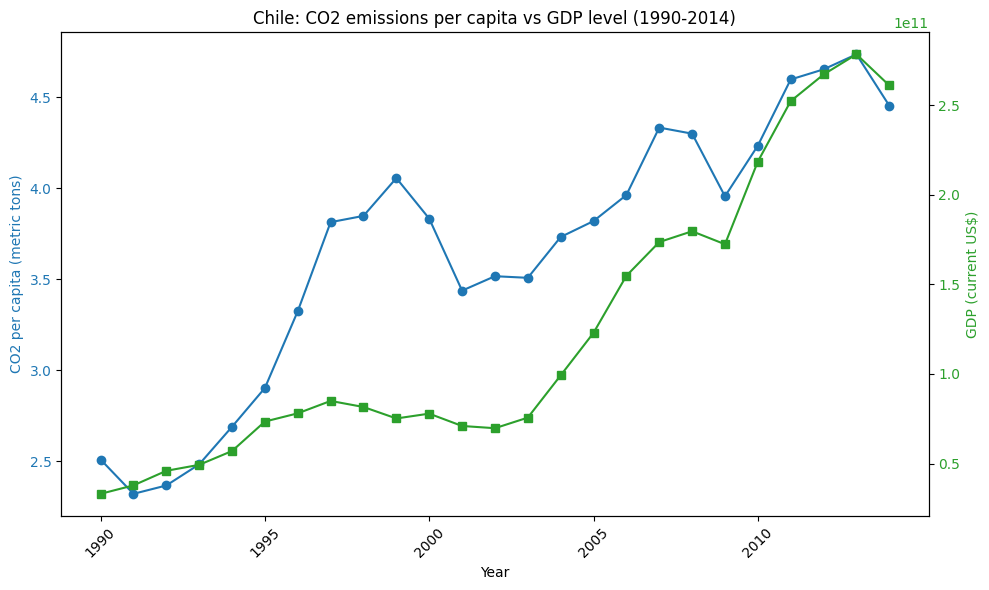

In [66]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(combined2["Year"], combined2["CO2_per_capita"], color="tab:blue", marker="o", label="CO2 per capita")
ax1.set_xlabel("Year")
ax1.set_ylabel("CO2 per capita (metric tons)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
plt.xticks(combined2["Year"][::5], rotation=45)

ax2 = ax1.twinx()
ax2.plot(combined2["Year"], combined2["GDP_level"], color="tab:green", marker="s", label="GDP (current US$)")
ax2.set_ylabel("GDP (current US$)", color="tab:green")
ax2.tick_params(axis="y", labelcolor="tab:green")

plt.title("Chile: CO2 emissions per capita vs GDP level (1990-2014)")
fig.tight_layout()
plt.savefig("chile_co2_vs_gdp_level.png", bbox_inches="tight", dpi=150)
plt.show()

Comparing CO2 emissions per capita to GDP level (rather than annual growth rate) reveals a much clearer relationship: both metrics trend upward together over 1990-2014, including a shared dip around 2008-2009 coinciding with the global financial crisis. This suggests emissions in Chile are more closely tied to the overall size of the economy than to short-term growth fluctuations a distinction that matters for policy, since it implies decoupling emissions from growth (a common climate policy goal) would require structural changes, not just short-term economic management